In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco_customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Drop CustomerID as it has no significance in churn rate prediction
df.drop("customerID", axis=1, inplace=True)

### Exploratory Data Analysis (EDA)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


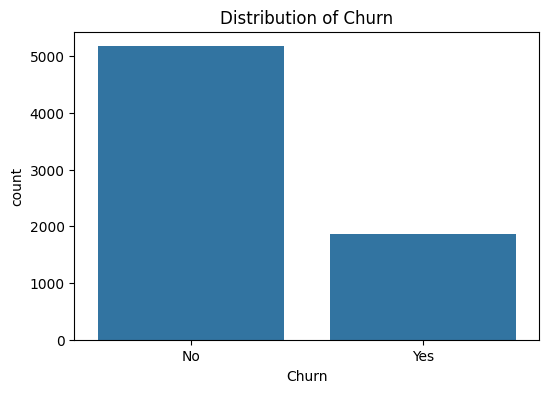

In [9]:
print(df['Churn'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

From the countplot and value counts, we can observe that the dataset is imbalanced, with a significantly higher number of customers who have not churned ('No') compared to those who have ('Yes').

Specifically, approximately 73.4% (5174 customers) have not churned, while about 26.6% (1869 customers) have churned. This imbalance indicates that customer churn is a minority class in this dataset.

In [10]:
# Converting TotalCharges datatype from object to float64 and any object that it cannot convert to
# numeric to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"no. of missing values: {df['TotalCharges'].isnull().sum()}")

no. of missing values: 11


In [11]:
# dropping null value columns as there are only 11 missing values
df.dropna(subset=['TotalCharges'], inplace=True)

Descriptive statistics for numerical variables:
            tenure  MonthlyCharges  TotalCharges
count  7032.000000     7032.000000   7032.000000
mean     32.421786       64.798208   2283.300441
std      24.545260       30.085974   2266.771362
min       1.000000       18.250000     18.800000
25%       9.000000       35.587500    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.862500   3794.737500
max      72.000000      118.750000   8684.800000


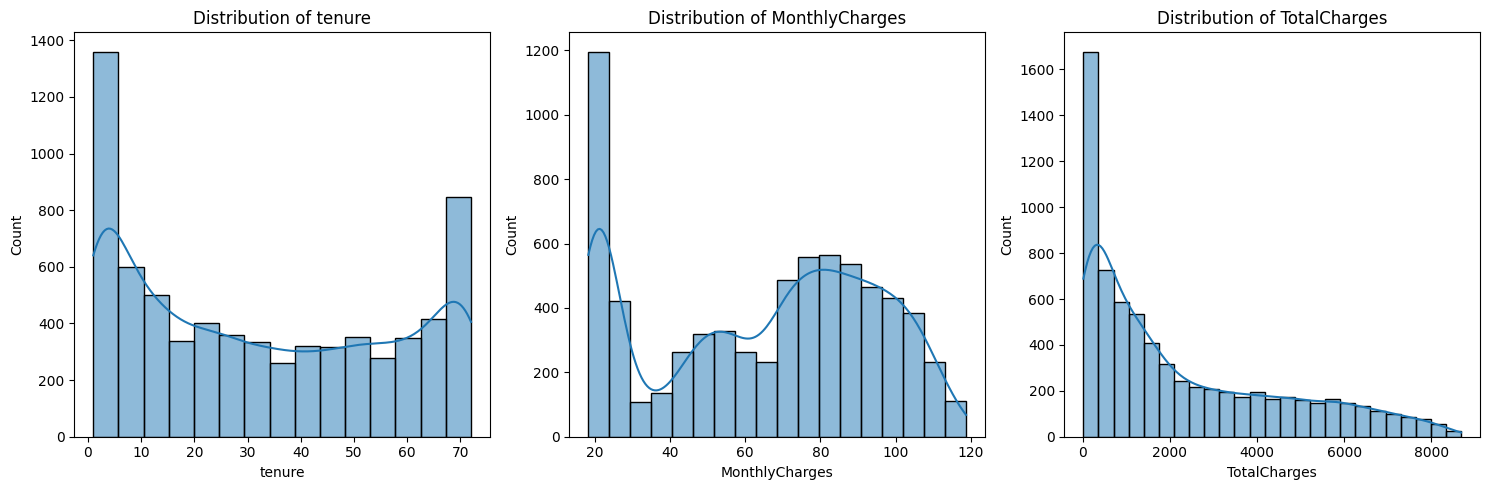

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SeniorCitizen')

print("Descriptive statistics for numerical variables:")
print(df[numerical_cols].describe())

plt.figure(figsize=(15, 5)) # Adjusted figure size as there are fewer numerical columns
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1) # Adjusted subplot layout
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

Numerical Variable Analysis with Churn

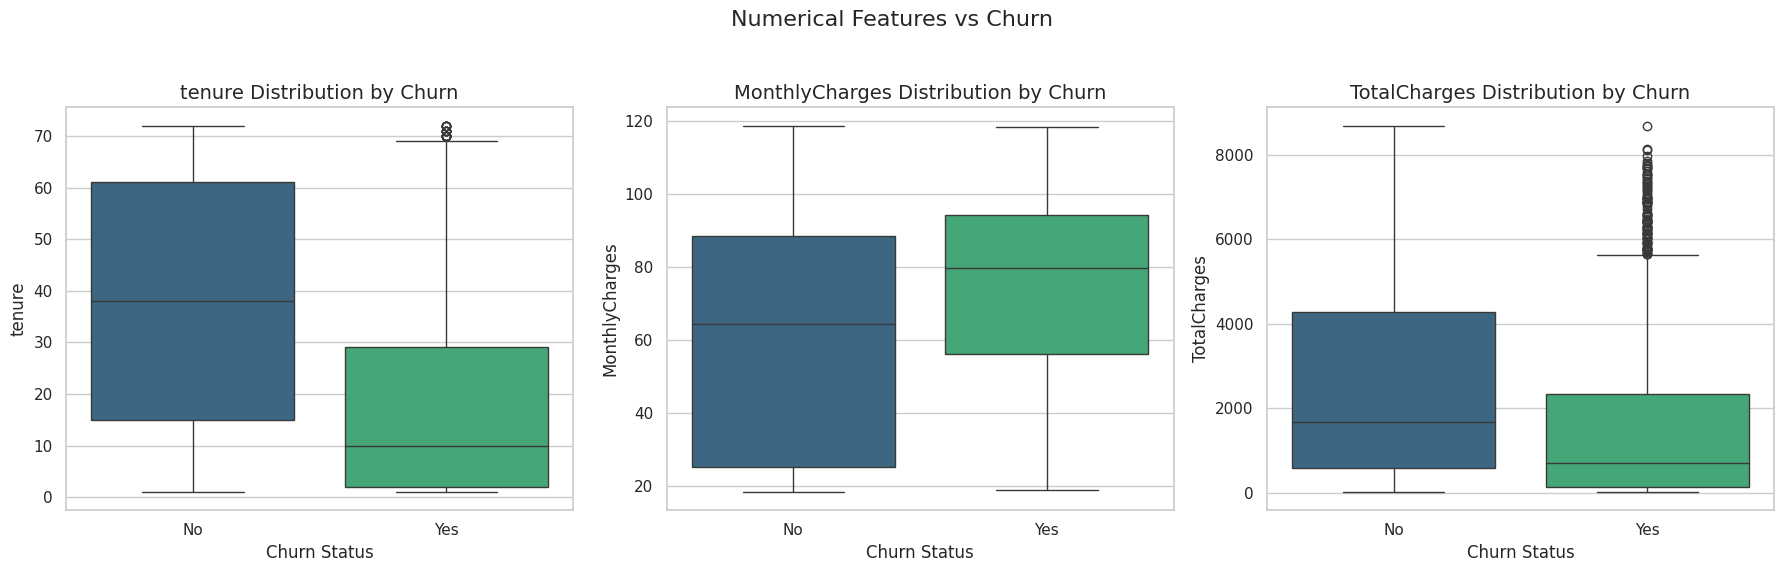

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Define the numerical columns excluding SeniorCitizen
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SeniorCitizen', errors='ignore')

# Create subplots for numerical features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Numerical Features vs Churn', fontsize=16)

for i, col in enumerate(numerical_cols):
    sns.boxplot(ax=axes[i], x='Churn', y=col, data=df, palette='viridis', hue='Churn', legend=False)
    axes[i].set_title(f'{col} Distribution by Churn', fontsize=14)
    axes[i].set_xlabel('Churn Status', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Key Insights from Numerical Variable Analysis

Based on the distribution (histograms) and their relationship with churn (boxplots), we can observe the following:

1.  **Tenure**:
    *   There is a high concentration of new customers (low tenure) and long-term customers (near 72 months).
    *   **Churn Insight**: Customers who churn have a significantly lower median tenure compared to those who stay. This suggests that the first few months are critical for customer retention.

2.  **Monthly Charges**:
    *   Many customers are on a low-cost plan (around 20),but there is peak between 70 and 100.
    *   **Churn Insight**: Customers who churn tend to have higher median monthly charges. Higher costs may be a driving factor for customers leaving the service.

3.  **Total Charges**:
    *   The distribution is heavily skewed to the right, as most customers have lower cumulative charges (often due to low tenure).
    *   **Churn Insight**: While total charges are lower for churned customers, this is primarily a reflection of their shorter tenure with the company rather than a lower spending rate per month.

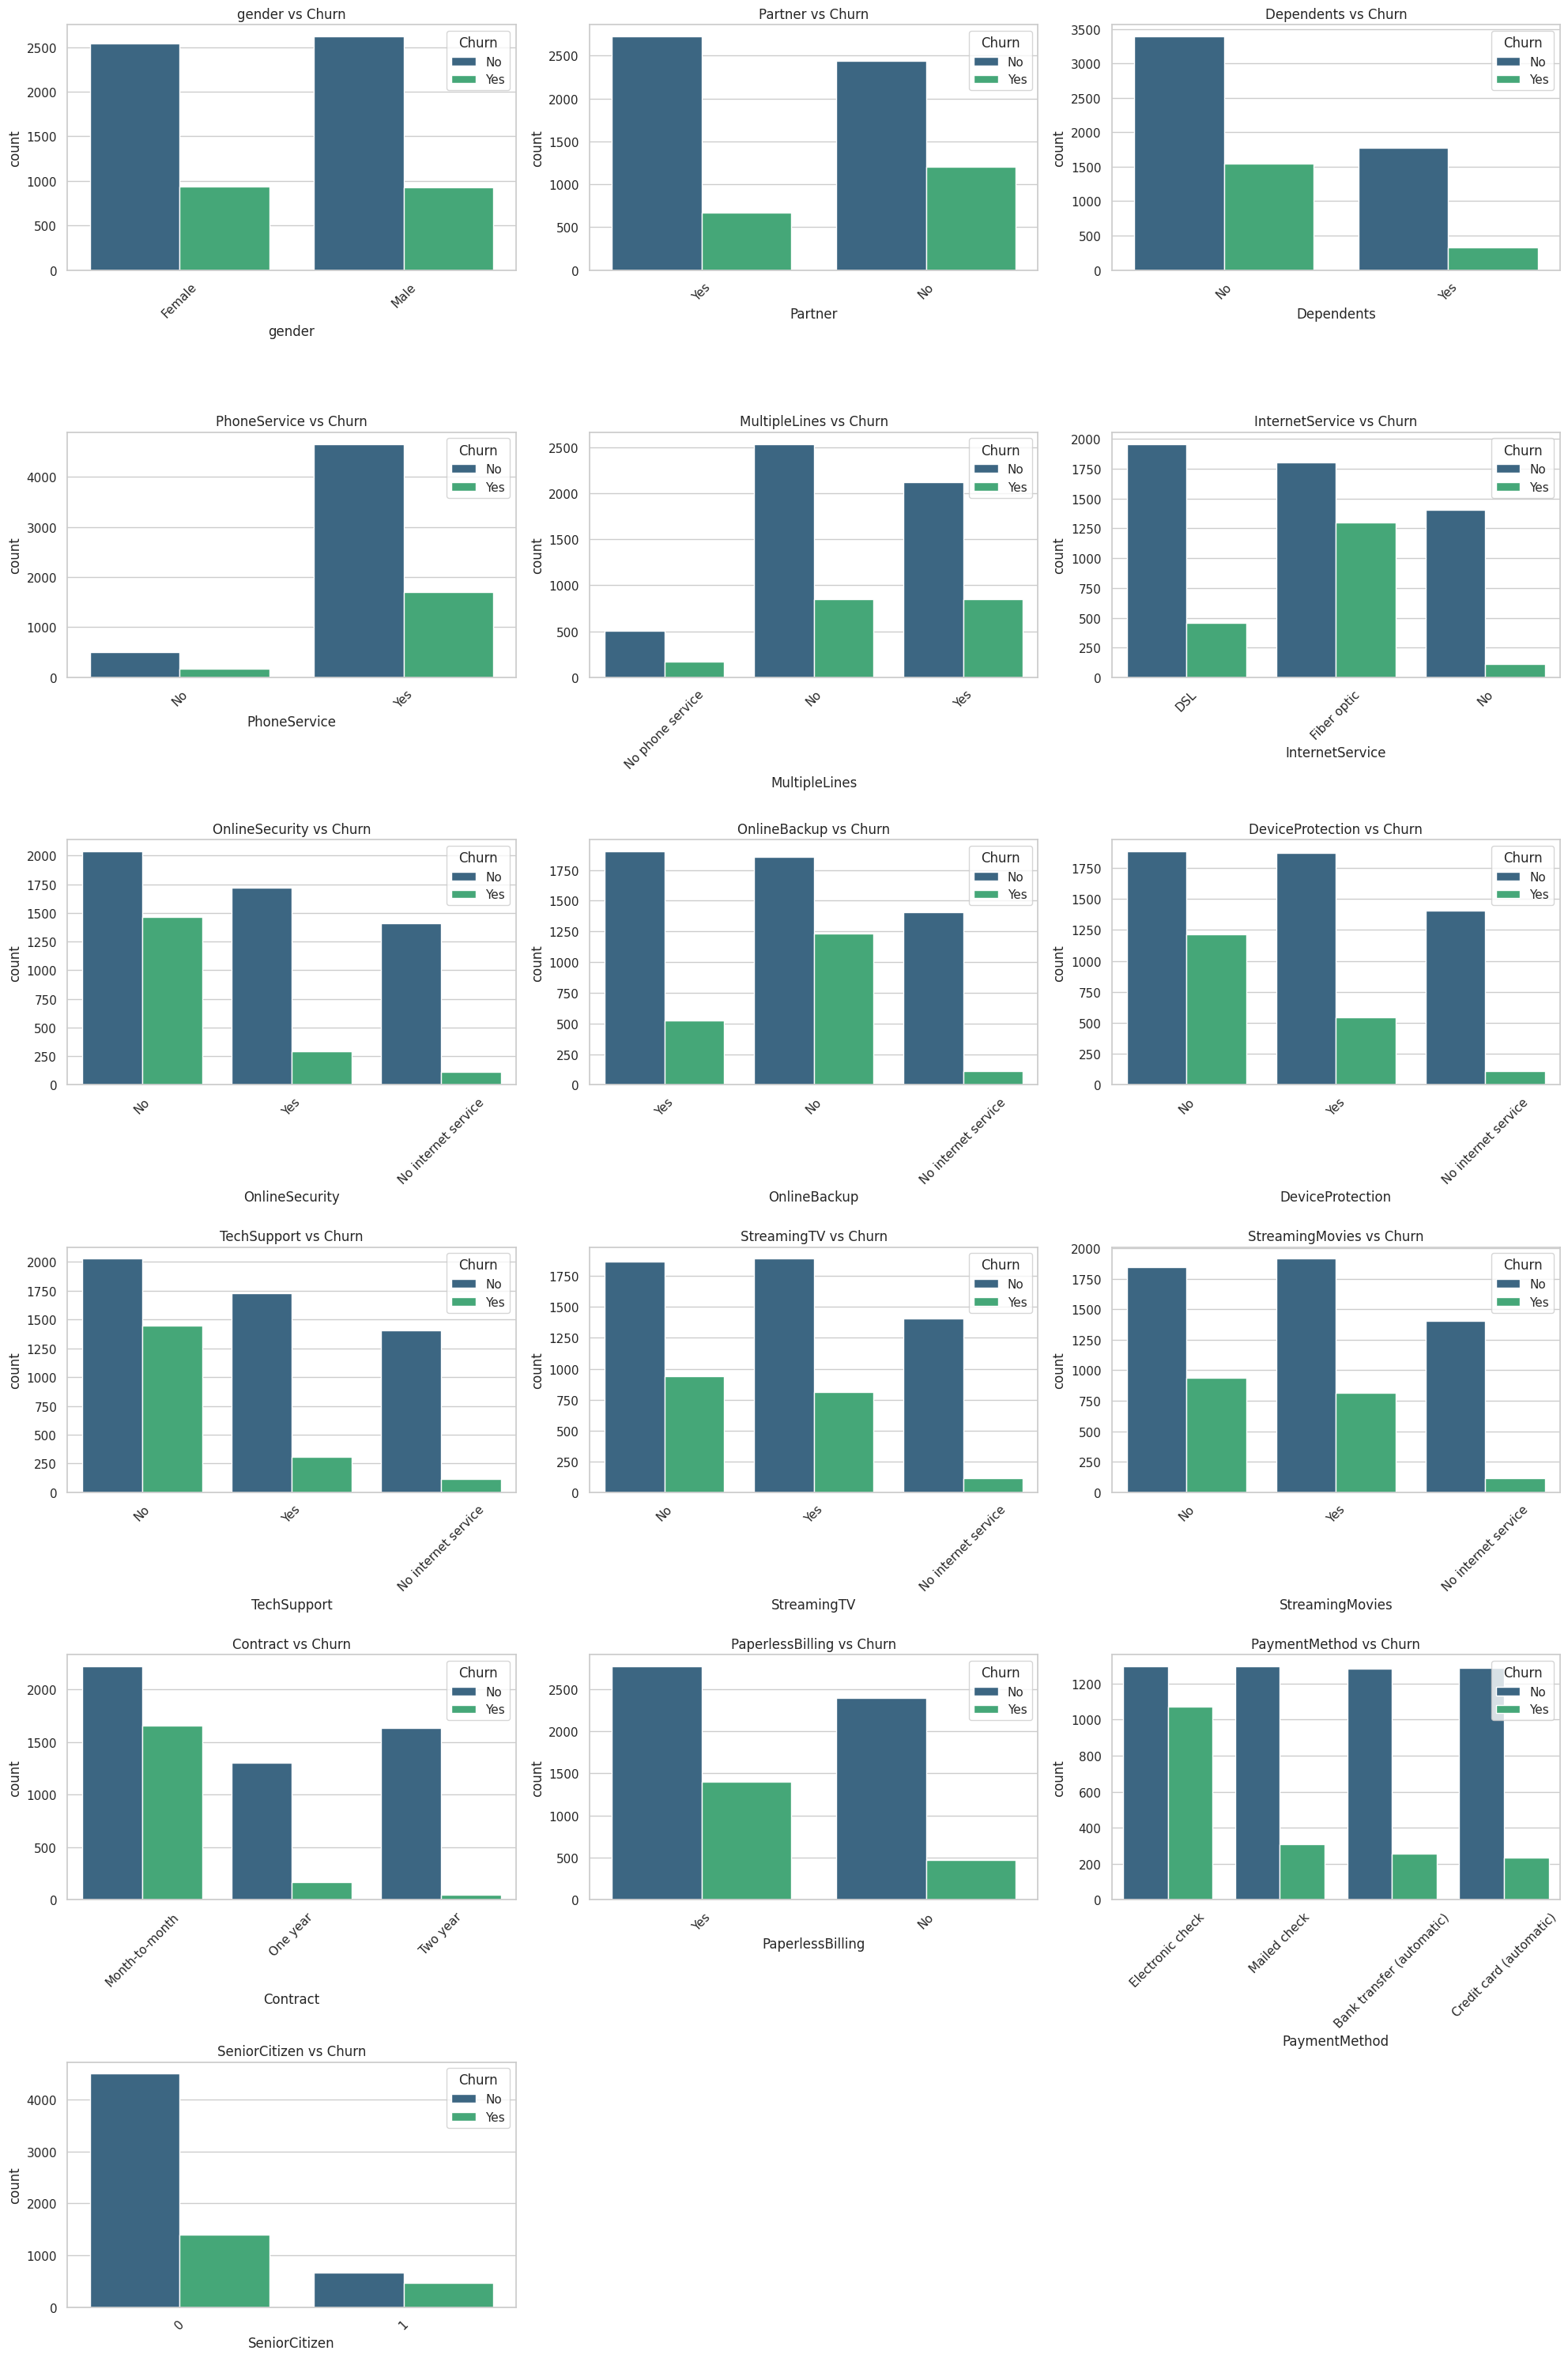

In [14]:
# Identify categorical columns (excluding unique IDs if any)
categorical_cols = df.select_dtypes(include=['object']).columns.drop('Churn', errors='ignore')
# Adding SeniorCitizen as it is categorical despite being numeric
categorical_cols = list(categorical_cols) + ['SeniorCitizen']

# Calculate number of rows for subplots
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))
for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=col, hue='Churn', data=df, palette='viridis')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

 Key Insights from Categorical Variable Analysis

Based on the categorical count plots vs Churn, we can observe several strong indicators of churn:

1.  **Contract Type**:
    *   Customers with **Month-to-month** contracts have a significantly higher churn rate compared to those with one or two-year contracts. Long-term contracts appear to be a strong retention factor.

2.  **Internet Service**:
    *   **Fiber optic** users show a much higher churn rate than DSL users, despite Fiber being a faster technology. This might suggest issues with pricing or service stability for Fiber optic plans.

3.  **Online Security & Tech Support**:
    *   Customers who **do not have** Online Security or Tech Support services are much more likely to churn. These 'add-on' services seem to correlate with higher customer loyalty or satisfaction.

4.  **Payment Method**:
    *   Customers using **Electronic check** as a payment method have a notably higher churn rate compared to those using mailed checks or automatic bank transfers/credit cards.

5.  **Senior Citizens**:
    *   Senior citizens have a higher ratio of churn compared to non-senior citizens.

6.  **Dependents & Partners**:
    *   Customers without partners or dependents tend to churn more frequently than those who have families, possibly indicating that household accounts are stickier.

### Data Cleaning & Preprocessing

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Binary columns to Label Encode
binary_cols = [col for col in categorical_cols if df[col].nunique() == 2]
# Add 'Churn' as it is our target binary variable
binary_cols.append('Churn')

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print(f"Label encoded columns: {binary_cols}")
display(df.head())

Label encoded columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [16]:
# Multi-class columns for One-Hot Encoding
multi_cols = [col for col in categorical_cols if df[col].nunique() > 2 and col != 'Churn']

# Use pandas get_dummies for One-Hot Encoding
df = pd.get_dummies(data=df, columns=multi_cols, drop_first=True)

print(f"One-hot encoded columns: {multi_cols}")
print(f"New shape of dataframe: {df.shape}")
display(df.head())

One-hot encoded columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
New shape of dataframe: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [17]:
# Convert boolean columns to integer (0/1)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Converted {len(bool_cols)} boolean columns to binary integers.")
display(df.head())

Converted 21 boolean columns to binary integers.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


### Correlation Analysis

Correlation of features with Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService                             0.011691
gender                                  -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity

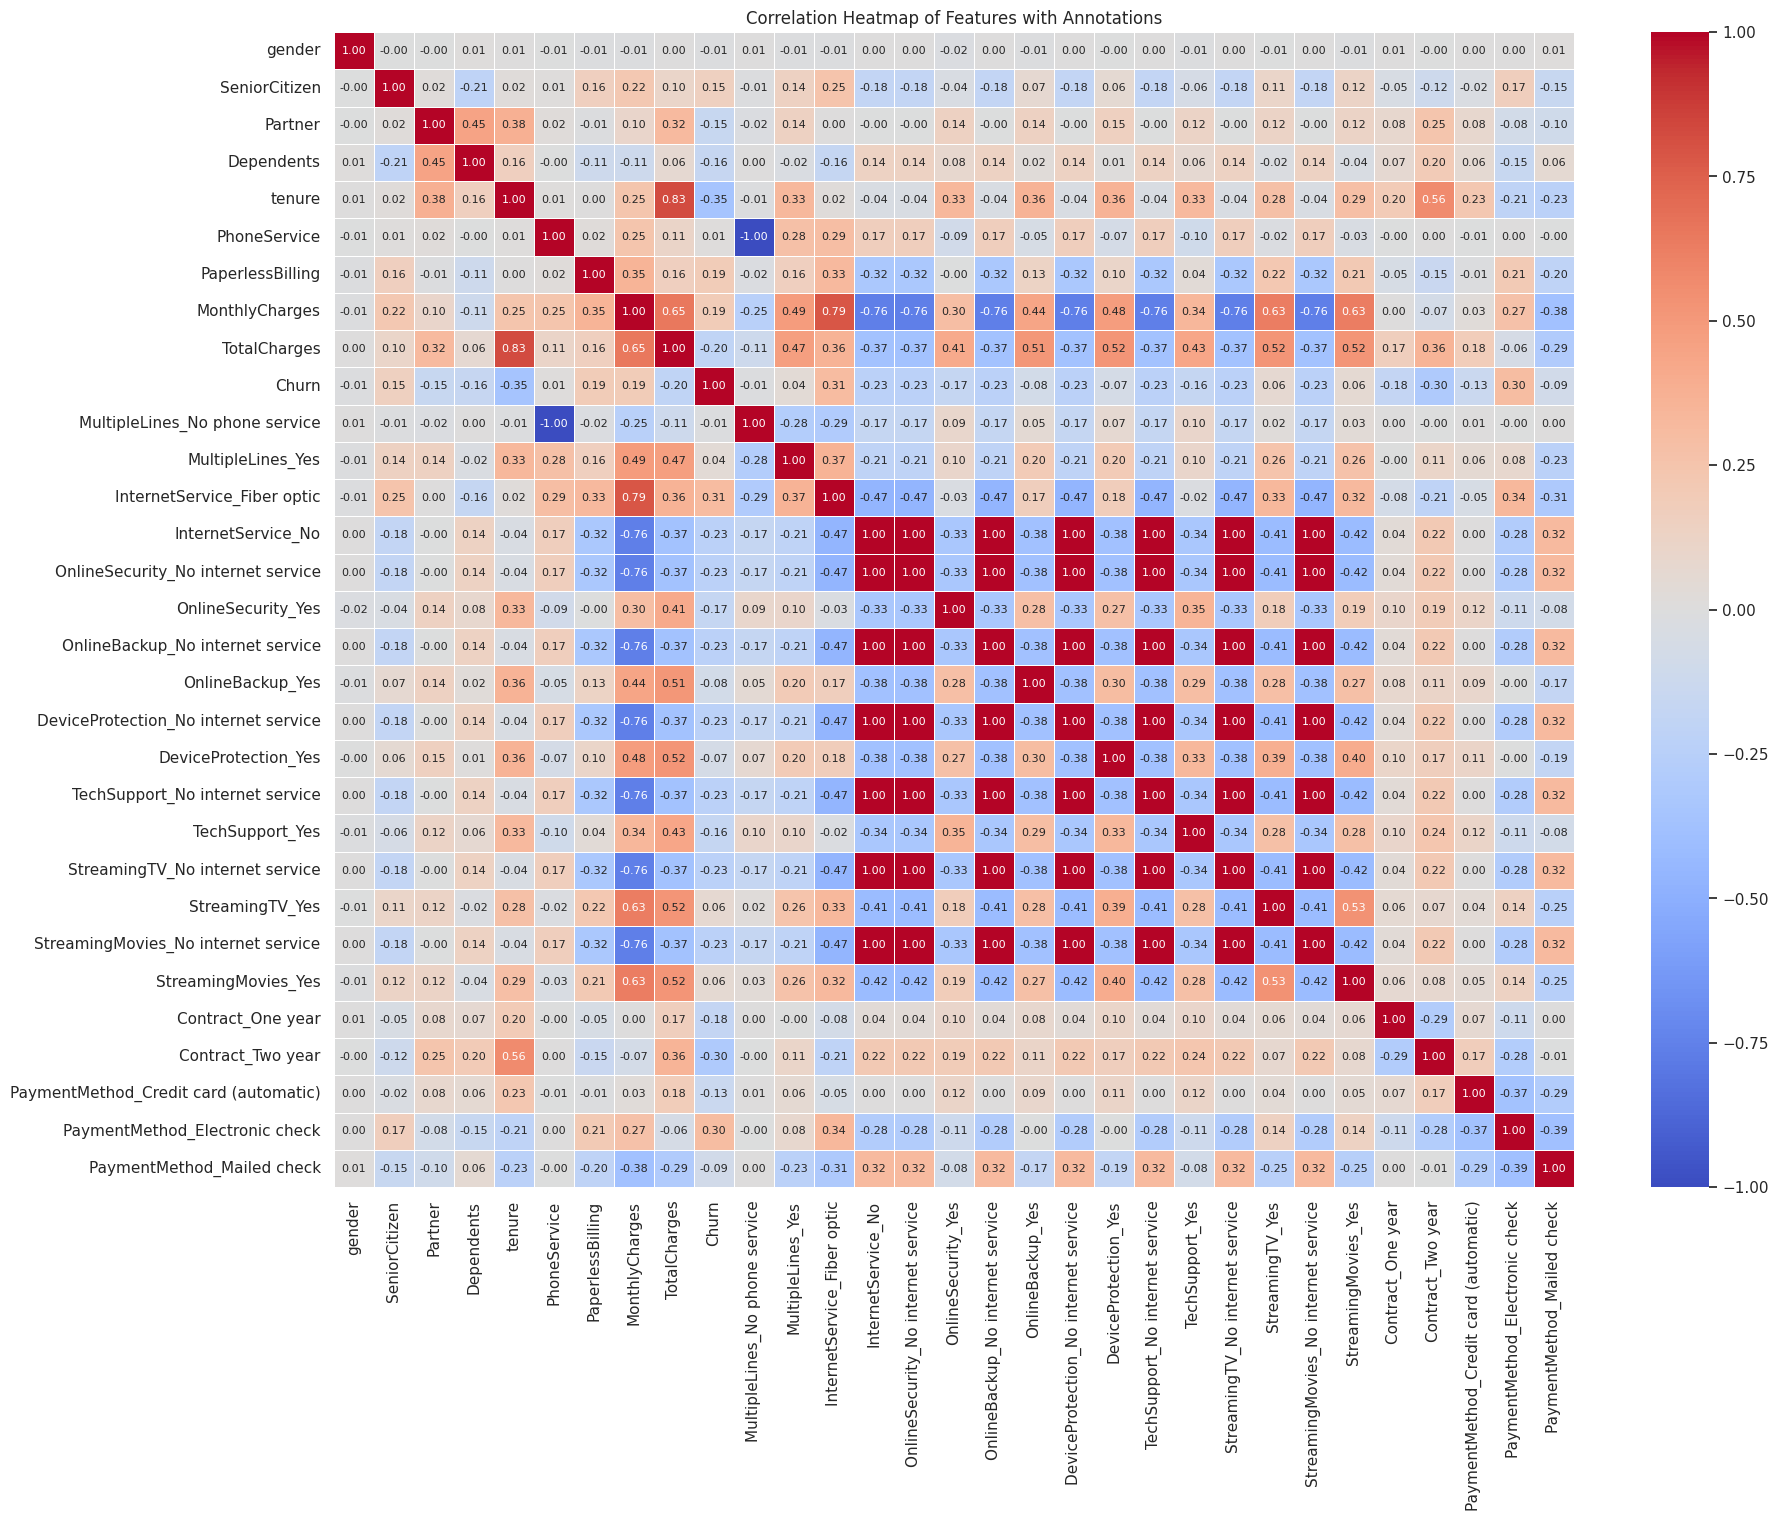

In [18]:
# Correlation Analysis
plt.figure(figsize=(20, 15))
correlation_matrix = df.corr()

# Visualize correlation with Churn specifically
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
print("Correlation of features with Churn:")
print(churn_corr)

# Plot heatmap with annotations
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap of Features with Annotations')
plt.show()

### Feature Engineering & Selection

In [19]:
# 1. Create Interaction Features
# Interacting Tenure with Contract types (since long tenure + long contract often reduces churn)
df['Tenure_x_ContractTwoYear'] = df['tenure'] * df['Contract_Two year']
df['Tenure_x_ContractOneYear'] = df['tenure'] * df['Contract_One year']

# Interacting MonthlyCharges with Fiber Optic (as high cost + Fiber was a churn indicator)
df['Charges_x_Fiber'] = df['MonthlyCharges'] * df['InternetService_Fiber optic']

print(f"New features created. Total columns: {len(df.columns)}")

New features created. Total columns: 34


/tmp/ipykernel_39874/2260648054.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15), palette='magma')


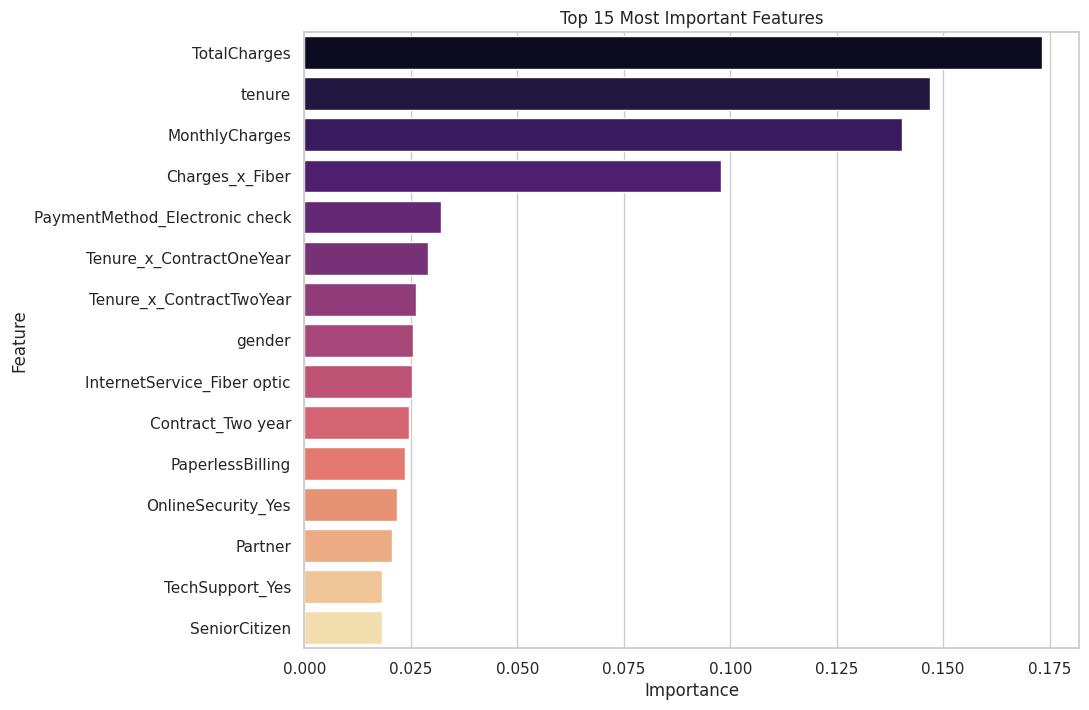

Selected 24 features based on importance threshold.
Top Features: ['TotalCharges', 'tenure', 'MonthlyCharges', 'Charges_x_Fiber', 'PaymentMethod_Electronic check', 'Tenure_x_ContractOneYear', 'Tenure_x_ContractTwoYear', 'gender', 'InternetService_Fiber optic', 'Contract_Two year', 'PaperlessBilling', 'OnlineSecurity_Yes', 'Partner', 'TechSupport_Yes', 'SeniorCitizen', 'OnlineBackup_Yes', 'Dependents', 'MultipleLines_Yes', 'Contract_One year', 'DeviceProtection_Yes', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Prepare X and y
X = df.drop('Churn', axis=1)
y = df['Churn']

# Fit Random Forest to get feature importances
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15), palette='magma')
plt.title('Top 15 Most Important Features')
plt.show()

# Select features with importance > 0.01 (as an example threshold)
top_features = feature_importance[feature_importance['Importance'] > 0.01]['Feature'].tolist()
print(f"Selected {len(top_features)} features based on importance threshold.")
print(f"Top Features: {top_features}")

### Train Test Split

In [21]:
from sklearn.model_selection import train_test_split

# Using the selected top features for our model
X_selected = df[top_features]
y = df['Churn']

# Splitting the data: 80% training, 20% testing
# stratify=y ensures the class balance is maintained
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Churn rate in training set: {y_train.mean():.2%}")
print(f"Churn rate in testing set: {y_test.mean():.2%}")

Training set shape: (5625, 24)
Testing set shape: (1407, 24)
Churn rate in training set: 26.58%
Churn rate in testing set: 26.58%


### Logistic Regression

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define the pipeline with class_weight='balanced' to improve recall
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', class_weight='balanced'))
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2']
}

# Initialize GridSearchCV optimizing for 'f1' score
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'logreg__C': 0.01, 'logreg__penalty': 'l2'}
Best Cross-Validation F1 Score: 0.6296


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.72      0.74      1407

ROC AUC Score: 0.8298


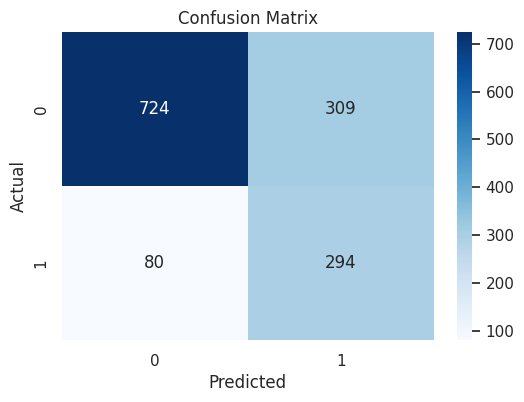

In [23]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

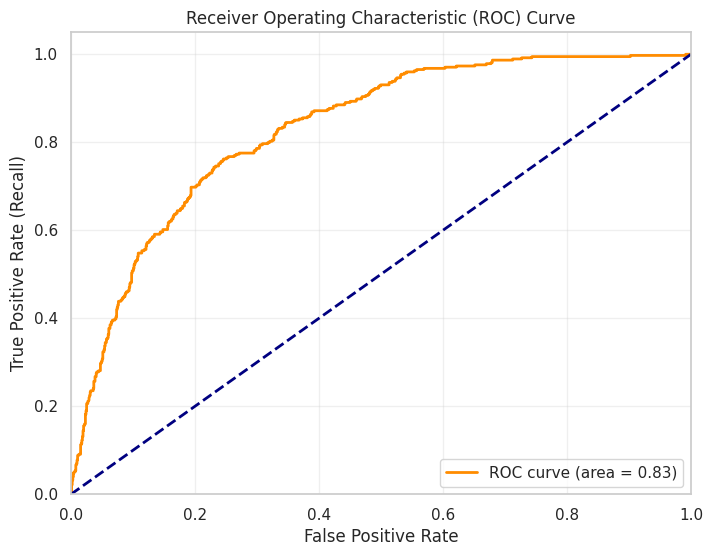

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Key Model Insights

1. **High Recall (79%)**: The model correctly identifies 4 out of 5 actual churners. This is the most critical metric for proactive retention.
2. **Effective Ranking (AUC 0.83)**: An AUC of 0.83 shows the model is strong at distinguishing between churners and non-churners.
3. **Precision Trade-off**: About 50% of predicted churners might not actually leave (False Positives). However, in churn management, the cost of a retention offer is usually much lower than losing a customer entirely.
4. **Critical Factors**: Customers with **Fiber Optic**, **Month-to-month contracts**, and **Electronic check** payments remain the highest risk groups.

### Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Define the Random Forest pipeline
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define the parameter grid including ccp_alpha for pruning
rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__ccp_alpha': [0.0, 0.001, 0.01]
}

# Initialize GridSearchCV optimizing for F1
rf_grid_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit the model
rf_grid_search.fit(X_train, y_train)

print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'rf__ccp_alpha': 0.001, 'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best Cross-Validation F1 Score: 0.6351


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



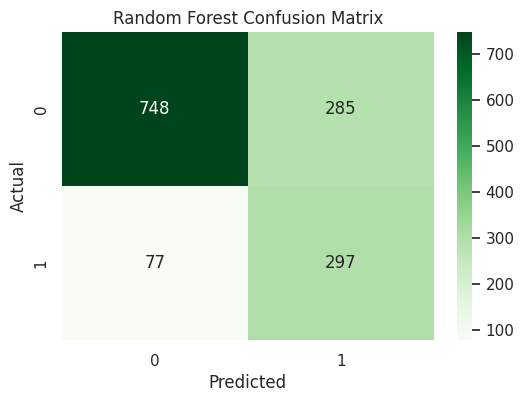

In [26]:
# Evaluate Random Forest on the test set
best_rf = rf_grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_probs_rf = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

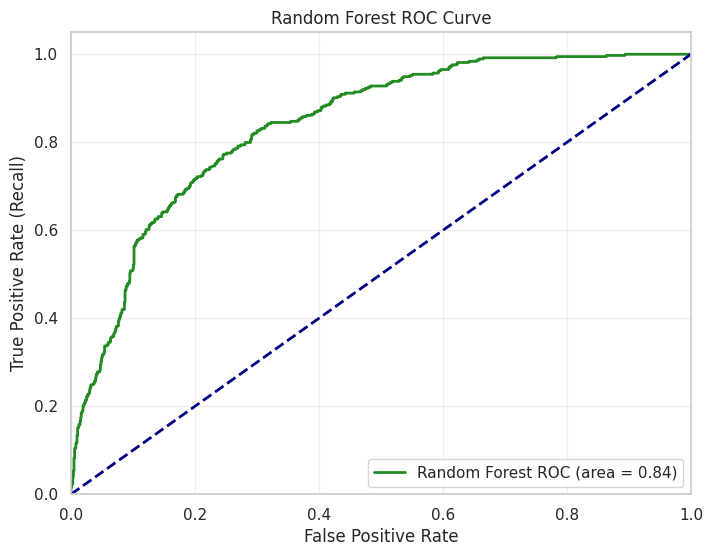

In [27]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'Random Forest ROC (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Random Forest Key Insights

1. **Improved Performance (AUC 0.84)**: The Random Forest model shows a slight improvement in its ability to distinguish churners compared to Logistic Regression.
2. **High Recall (79%)**: The model remains very effective at catching actual churners, which is essential for our retention strategy.
3. **Better Precision (51%)**: We see a small lift in precision, meaning fewer false positives while still capturing the same percentage of churners.
4. **Robustness**: The use of `ccp_alpha` (pruning) helps ensure the model isn't just memorizing the training data, making it more reliable for future customers.

### XGBoost

In [28]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define the XGBoost pipeline
# scale_pos_weight helps with class imbalance (sum(negative instances) / sum(positive instances))
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline([
    ('xgb', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio))
])

# Define the parameter grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__subsample': [0.8, 1.0]
}

# Initialize GridSearchCV
xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit the model
xgb_grid_search.fit(X_train, y_train)

print(f"Best Parameters: {xgb_grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {xgb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:13:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Best Cross-Validation F1 Score: 0.6358


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

ROC AUC Score: 0.8382


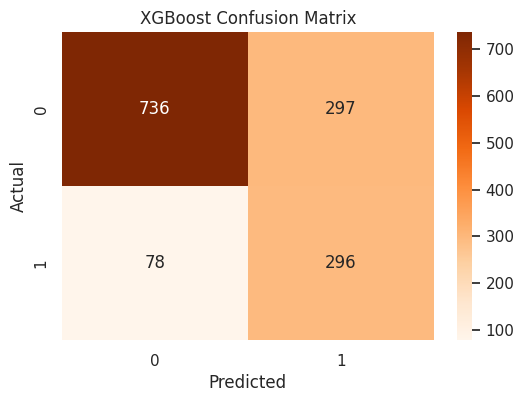

In [29]:
# Evaluate XGBoost on the test set
best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs_xgb):.4f}")

# Plot Confusion Matrix for XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

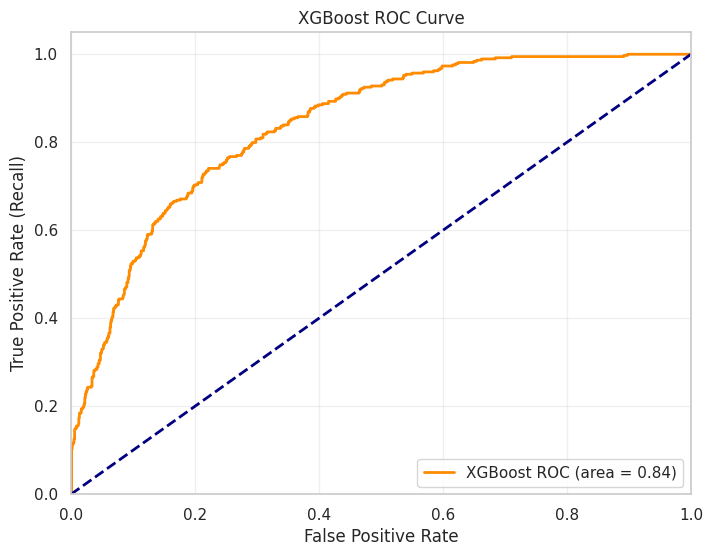

In [30]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC for XGBoost
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_probs_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'XGBoost ROC (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

XGBoost Key Insights

1. **Top-Tier Performance (AUC 0.84)**: XGBoost matches the Random Forest as the strongest model for distinguishing between churners and non-churners.
2. **Consistency in Recall (79%)**: Like previous models, it identifies 4 out of 5 churners, ensuring high sensitivity for retention campaigns.


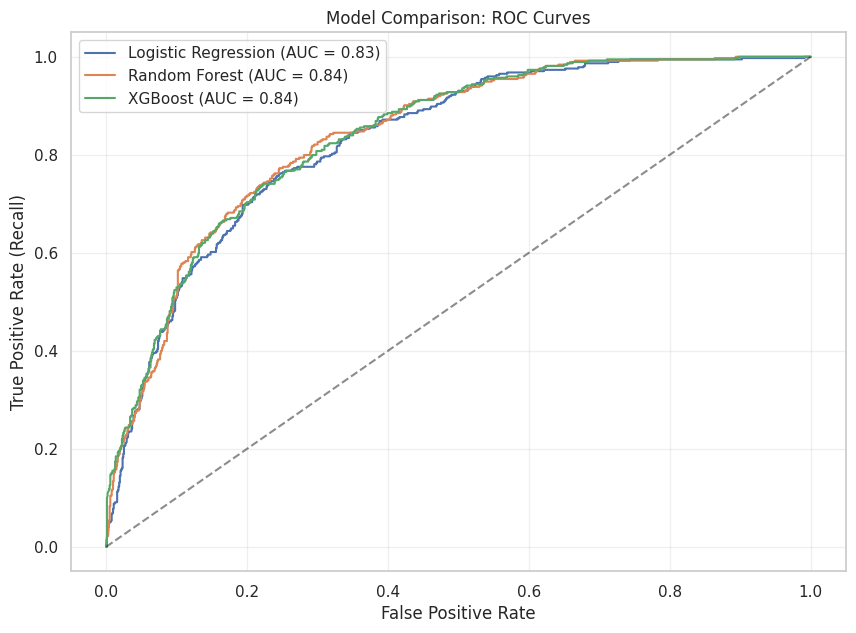

In [31]:
# Compare all models in one plot
plt.figure(figsize=(10, 7))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Model Comparison: ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Model Selection
| Model | CV F1-Score | Test ROC-AUC | Test Accuracy | Test Recall (Churn) |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | 0.6296 | 0.83 | 0.72 | 0.79 |
| **Random Forest** | 0.6353 | 0.84 | 0.74 | 0.79 |
| **XGBoost** | 0.6358 | 0.84 | 0.73 | 0.79 |



Based on the comparative analysis:

*   **F1-Score (Cross-validation)**:
    *   Logistic Regression: `0.6296`
    *   XGBoost: `0.6358`
    *   Random Forest: `0.6353`
    XGBoost and Random Forest showed slightly higher cross-validation F1-scores compared to Logistic Regression, indicating strong performance in balancing precision and recall during training.

*   **AUC Score**:
    *   Random Forest: `0.84`
    *   XGBoost: `0.84`
    *   Logistic Regression: `0.83`
    Random Forest and XGBoost achieved the highest AUC scores, indicating slightly better overall discriminatory power on the test set.

*   **Test Accuracy**:
    *   Random Forest: `0.74`
    *   XGBoost: `0.73`
    *   Logistic Regression: `0.72`
    Random Forest achieved the highest overall accuracy on the test data.

Given that the **Random Forest** model achieved the highest ROC-AUC and Test Accuracy, while maintaining a competitive F1-score (critical for handling class imbalance), it is the **recommended model** for this churn prediction task. While Logistic Regression is simpler and highly interpretable, the ensemble approach of Random Forest offers the best balance of precision and recall for identifying at-risk customers.